CNN FOR MNIST HANDWRITTEN DIGIT CLASSIFICATION
TensorFlow Version : 2.21.0

Loading MNIST Dataset...
Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


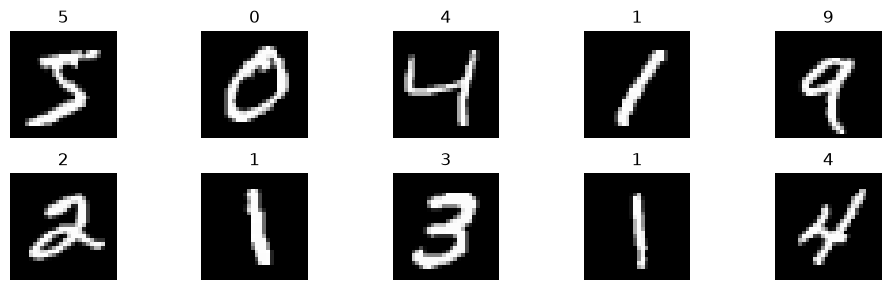


Preprocessing Data...
Training Shape : (60000, 28, 28, 1)
Testing Shape  : (10000, 28, 28, 1)

Building CNN Model...

MODEL SUMMARY



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN...

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9471 - loss: 0.1764 - val_accuracy: 0.9803 - val_loss: 0.0634
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9834 - loss: 0.0526 - val_accuracy: 0.9844 - val_loss: 0.0506
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9892 - loss: 0.0355 - val_accuracy: 0.9881 - val_loss: 0.0448
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.9915 - loss: 0.0270 - val_accuracy: 0.9882 - val_loss: 0.0416
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9937 - loss: 0.0194 - val_accuracy: 0.9883 - val_loss: 0.0408
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9950 - loss: 0.0151 - val_accuracy: 0.9887 - val_loss: 0.0417
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9962 - loss: 0.0116 - val_accuracy: 0.9883 - val_loss: 0.0441
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9962

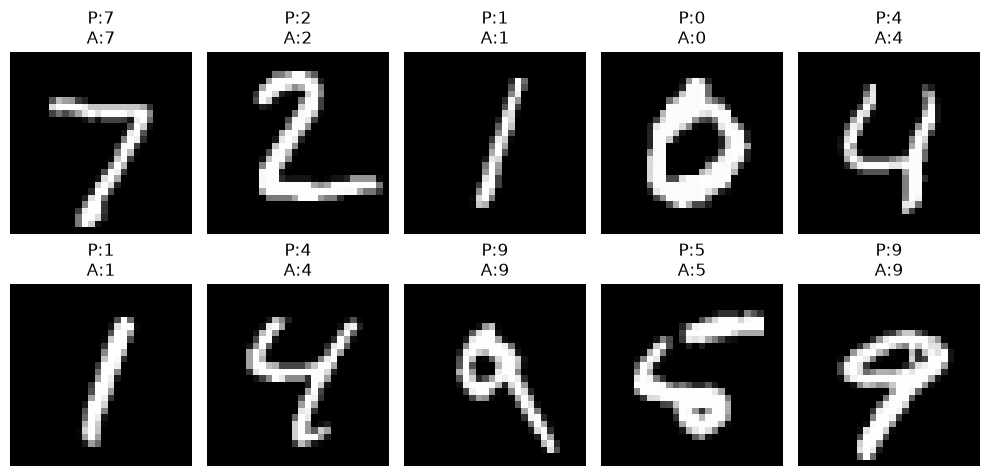

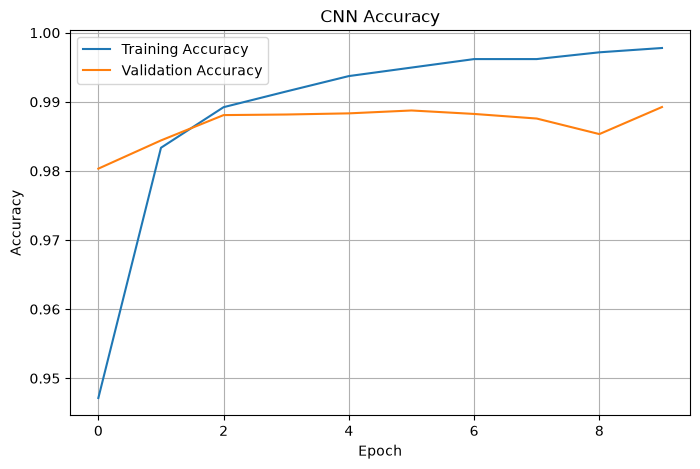

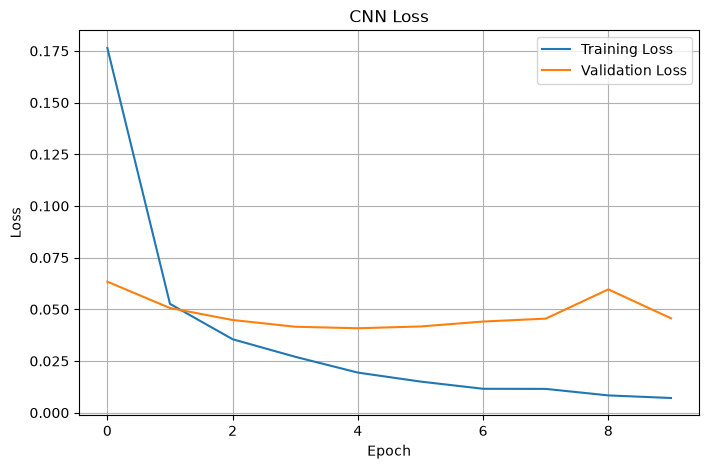


Program Executed Successfully.


In [1]:
# cnn_mnist.py

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("CNN FOR MNIST HANDWRITTEN DIGIT CLASSIFICATION")
print("=" * 60)

print("TensorFlow Version :", tf.__version__)

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------

print("\nLoading MNIST Dataset...")

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)

# --------------------------------------------------
# Display Sample Images
# --------------------------------------------------

plt.figure(figsize=(10,3))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_train[i], cmap="gray")

    plt.title(y_train[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

# --------------------------------------------------
# Preprocessing
# --------------------------------------------------

print("\nPreprocessing Data...")

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# One-Hot Encoding

y_train = tf.keras.utils.to_categorical(y_train,10)
y_test = tf.keras.utils.to_categorical(y_test,10)

print("Training Shape :", x_train.shape)
print("Testing Shape  :", x_test.shape)

# --------------------------------------------------
# Build CNN Model
# --------------------------------------------------

print("\nBuilding CNN Model...")

model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(28,28,1)),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),

    tf.keras.layers.Dense(10,activation="softmax")

])

# --------------------------------------------------
# Compile Model
# --------------------------------------------------

model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

print("\nMODEL SUMMARY\n")

model.summary()

# --------------------------------------------------
# Train Model
# --------------------------------------------------

print("\nTraining CNN...\n")

history = model.fit(

    x_train,

    y_train,

    epochs=10,

    batch_size=64,

    validation_split=0.2,

    verbose=1

)

# --------------------------------------------------
# Evaluate
# --------------------------------------------------

print("\nEvaluating Model...\n")

loss, accuracy = model.evaluate(

    x_test,

    y_test,

    verbose=0

)

print(f"Test Loss     : {loss:.4f}")

print(f"Test Accuracy : {accuracy:.4f}")

# --------------------------------------------------
# Predictions
# --------------------------------------------------

predictions = model.predict(x_test[:10])

print("\nSample Predictions\n")

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[i].reshape(28,28), cmap="gray")

    predicted = np.argmax(predictions[i])

    actual = np.argmax(y_test[i])

    plt.title(f"P:{predicted}\nA:{actual}")

    plt.axis("off")

plt.tight_layout()

plt.show()

# --------------------------------------------------
# Accuracy Graph
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Training Accuracy")

plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.title("CNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# --------------------------------------------------
# Loss Graph
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Training Loss")

plt.plot(history.history["val_loss"],label="Validation Loss")

plt.title("CNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

print("\nProgram Executed Successfully.")